In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dicionario de dados

- ano: Ano de aplicação da avaliação estadual
- id_municipio: ID município de 7 dígitos
- id_escola: Máscara do códigoo da escola (códigos fictícios)
- id_aluno: Código do aluno
- caderno: Código do caderno atribuído ao aluno na prova de língua portuguesa
- serie: Ano escolar
- rede: Dependência administrativa da escola
- presenca: Indicador de presença na prova de língua portuguesa
- preenchimento_caderno: Indicador de preenchimento da prova de língua portuguesa
- alfabetizado: Indica se o aluno, mediante o resultado da avaliação estadual, é considerado alfabetizado
- proficiencia: Proficiência do aluno em língua portuguesa calculada na escala equalizada com o SAEB
- peso_aluno: Peso do aluno na prova de língua portuguesa
- mun_taxa_alfabetizacao: Percentual dos alunos avaliados no município que foram considerados, mediante o resultado da avaliação estadual, como alfabetizados
- mun_media_portugues: Média ponderada do município na avaliação estadual na disciplina Língua Portuguesa (LP) equalizada com o SAEB

In [2]:
# Carregando tabelas

ANOS = [2023, 2024]
df = pd.concat([
    pd.read_parquet(f"../data/silver/integrado/year={ano}/dados.parquet")
    for ano in ANOS
], ignore_index=True)

In [3]:
print(f'tamanho do nosso dataset (Linhas, Colunas): {df.shape}')

tamanho do nosso dataset (Linhas, Colunas): (3355822, 31)


In [4]:
df.head()

,ano,id_municipio,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,...,mun_prop_nivel_5,mun_prop_nivel_6,mun_prop_nivel_7,mun_prop_nivel_8,mun_nivel_alfabetizacao,mun_percentual_participacao,gap_mun_meta_2030,uf_taxa_alfabetizacao,uf_media_portugues,gap_mun_vs_uf
0,2023,3300704,60025977,33014516,1,2,Municipal,1,1,1,...,NaN,NaN,NaN,NaN,2.0,77.39,-25.42,52.13,737.3032,2.45
1,2023,3121605,60021971,31008498,1,2,Municipal,1,1,1,...,NaN,NaN,NaN,NaN,2.0,91.70,-20.46,58.74,750.4243,0.80
2,2023,3157807,60018571,31151092,1,2,Estadual,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.65,756.3436,-9.90
3,2023,4204806,60035456,42032360,1,2,Municipal,1,1,1,...,NaN,NaN,NaN,NaN,1.0,79.47,-31.44,62.04,747.7686,-13.48
4,2023,4204806,60035456,42032357,1,2,Municipal,1,1,1,...,NaN,NaN,NaN,NaN,1.0,79.47,-31.44,62.04,747.7686,-13.48


In [5]:
df.tail()

,ano,id_municipio,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,...,mun_prop_nivel_5,mun_prop_nivel_6,mun_prop_nivel_7,mun_prop_nivel_8,mun_nivel_alfabetizacao,mun_percentual_participacao,gap_mun_meta_2030,uf_taxa_alfabetizacao,uf_media_portugues,gap_mun_vs_uf
3355817,2024,4322400,60038978,43098836,9,2,Municipal,1,1,0,...,22.13,14.29,3.64,1.06,1.0,74.64,-32.70,44.23,733.9263,3.07
3355818,2024,2602902,60013156,26035176,9,2,Municipal,1,1,0,...,28.06,14.31,2.67,0.62,2.0,91.65,-29.28,60.76,747.2800,-10.04
3355819,2024,4314902,60038096,43065853,9,2,Estadual,1,1,0,...,13.82,8.22,3.29,1.28,NaN,NaN,NaN,45.63,734.9670,-14.33
3355820,2024,3167202,60019847,31182116,9,2,Municipal,1,1,1,...,31.10,15.78,4.61,1.91,3.0,87.26,-19.65,71.45,757.4100,-11.10
3355821,2024,5300108,60042409,53014042,9,2,Estadual,1,1,0,...,33.05,13.13,3.10,0.71,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3355822 entries, 0 to 3355821
Data columns (total 31 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   ano                          int64  
 1   id_municipio                 int64  
 2   id_escola                    int64  
 3   id_aluno                     int64  
 4   caderno                      int64  
 5   serie                        int64  
 6   rede                         str    
 7   presenca                     int64  
 8   preenchimento_caderno        int64  
 9   alfabetizado                 int64  
 10  proficiencia                 float64
 11  peso_aluno                   float64
 12  sigla_uf                     str    
 13  regiao                       str    
 14  mun_taxa_alfabetizacao       float64
 15  mun_media_portugues          float64
 16  mun_prop_nivel_0             float64
 17  mun_prop_nivel_1             float64
 18  mun_prop_nivel_2             float64
 19  mun_prop_ni

In [8]:
nulos = df.isnull().mean().sort_values(ascending=False) * 100
nulos = nulos[nulos > 0]
print("Percentual de nulos por coluna:")
nulos

Percentual de nulos por coluna:


mun_prop_nivel_6               44.790099
mun_prop_nivel_4               44.790099
mun_prop_nivel_5               44.790099
mun_prop_nivel_3               44.790099
mun_prop_nivel_2               44.790099
mun_prop_nivel_1               44.790099
mun_prop_nivel_8               44.790099
mun_prop_nivel_7               44.790099
mun_prop_nivel_0               44.790099
mun_nivel_alfabetizacao        13.037908
mun_percentual_participacao    13.037908
gap_mun_meta_2030              12.731545
gap_mun_vs_uf                   0.664278
uf_taxa_alfabetizacao           0.658885
uf_media_portugues              0.658885
proficiencia                    0.035312
peso_aluno                      0.035312
mun_taxa_alfabetizacao          0.005394
mun_media_portugues             0.005394
dtype: float64

In [9]:
# visualizando registros com nulos
df[df['proficiencia'].isna()]

,ano,id_municipio,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,...,mun_prop_nivel_5,mun_prop_nivel_6,mun_prop_nivel_7,mun_prop_nivel_8,mun_nivel_alfabetizacao,mun_percentual_participacao,gap_mun_meta_2030,uf_taxa_alfabetizacao,uf_media_portugues,gap_mun_vs_uf
1412,2023,5002704,60040533,50495840,10,2,Municipal,1,0,0,...,NaN,NaN,NaN,NaN,1.0,83.99,-38.39,47.53,736.0729,-5.92
16692,2023,5005004,60040388,50610950,7,2,Municipal,1,0,0,...,NaN,NaN,NaN,NaN,0.0,83.83,-44.72,47.53,736.0729,-12.25
18535,2023,5002704,60040515,50499850,9,2,Municipal,1,0,0,...,NaN,NaN,NaN,NaN,1.0,83.99,-38.39,47.53,736.0729,-5.92
20848,2023,5006606,60040454,50686870,10,2,Municipal,1,0,0,...,NaN,NaN,NaN,NaN,2.0,91.34,-22.24,47.53,736.0729,10.23
38928,2023,5003306,60040224,50538940,1,2,Municipal,1,0,0,...,NaN,NaN,NaN,NaN,0.0,86.90,-40.31,47.53,736.0729,-7.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3339636,2024,2211100,60006574,22031110,16,2,Municipal,1,0,0,...,13.33,11.56,3.78,1.54,0.0,93.30,-44.79,59.76,754.7700,-24.55
3340752,2024,4316907,60038314,43075352,17,2,Municipal,1,0,0,...,17.10,11.85,3.02,1.98,0.0,77.89,-40.30,44.23,733.9263,-4.53
3345402,2024,4314902,60038070,43064732,20,2,Municipal,1,0,0,...,9.29,5.27,1.54,0.51,NaN,NaN,NaN,44.23,733.9263,-23.83
3346519,2024,2211001,60006565,22011167,21,2,Municipal,1,0,0,...,21.22,17.99,9.25,3.03,2.0,91.73,-22.75,59.76,754.7700,-2.51


# Análise Descritiva

In [10]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ano,3355822.0,NaN,NaN,NaN,2023.552104,0.497278,2023.0,2023.0,2024.0,2024.0,2024.0
id_municipio,3355822.0,NaN,NaN,NaN,3215675.198125,1033473.778278,1100015.0,2510501.0,3170107.0,4106902.0,5300108.0
id_escola,3355822.0,NaN,NaN,NaN,60021802.2615,12549.161898,60000001.0,60011249.0,60022103.0,60032799.75,60042811.0
id_aluno,3355822.0,NaN,NaN,NaN,32097807.577066,10333965.966297,11000001.0,25025676.0,31189940.0,41041128.0,53027700.0
caderno,3355822.0,NaN,NaN,NaN,10.708115,6.137732,1.0,5.0,11.0,16.0,43.0
serie,3355822.0,NaN,NaN,NaN,2.0,0.0,2.0,2.0,2.0,2.0,2.0
rede,3355822,2,Municipal,2983123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
presenca,3355822.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
preenchimento_caderno,3355822.0,NaN,NaN,NaN,0.999647,0.018788,0.0,1.0,1.0,1.0,1.0
alfabetizado,3355822.0,NaN,NaN,NaN,0.591369,0.491581,0.0,0.0,1.0,1.0,1.0


In [16]:
df.columns

Index(['ano', 'id_municipio', 'id_escola', 'id_aluno', 'caderno', 'serie',
       'rede', 'presenca', 'preenchimento_caderno', 'alfabetizado',
       'proficiencia', 'peso_aluno', 'sigla_uf', 'regiao',
       'mun_taxa_alfabetizacao', 'mun_media_portugues', 'mun_prop_nivel_0',
       'mun_prop_nivel_1', 'mun_prop_nivel_2', 'mun_prop_nivel_3',
       'mun_prop_nivel_4', 'mun_prop_nivel_5', 'mun_prop_nivel_6',
       'mun_prop_nivel_7', 'mun_prop_nivel_8', 'mun_nivel_alfabetizacao',
       'mun_percentual_participacao', 'gap_mun_meta_2030',
       'uf_taxa_alfabetizacao', 'uf_media_portugues', 'gap_mun_vs_uf'],
      dtype='str')

In [18]:
lista_variaveis =  [
'alfabetizado','proficiencia','mun_taxa_alfabetizacao',
'mun_media_portugues','mun_taxa_alfabetizacao',
'mun_media_portugues','mun_prop_nivel_0','mun_prop_nivel_1',
'mun_prop_nivel_2', 'mun_prop_nivel_3', 'mun_prop_nivel_4',
'mun_prop_nivel_5', 'mun_prop_nivel_6',
'mun_prop_nivel_7', 'mun_prop_nivel_8', 'mun_nivel_alfabetizacao',
'mun_percentual_participacao', 'gap_mun_meta_2030',
'uf_taxa_alfabetizacao', 'uf_media_portugues', 'gap_mun_vs_uf'
]

df_dist = df[lista_variaveis]

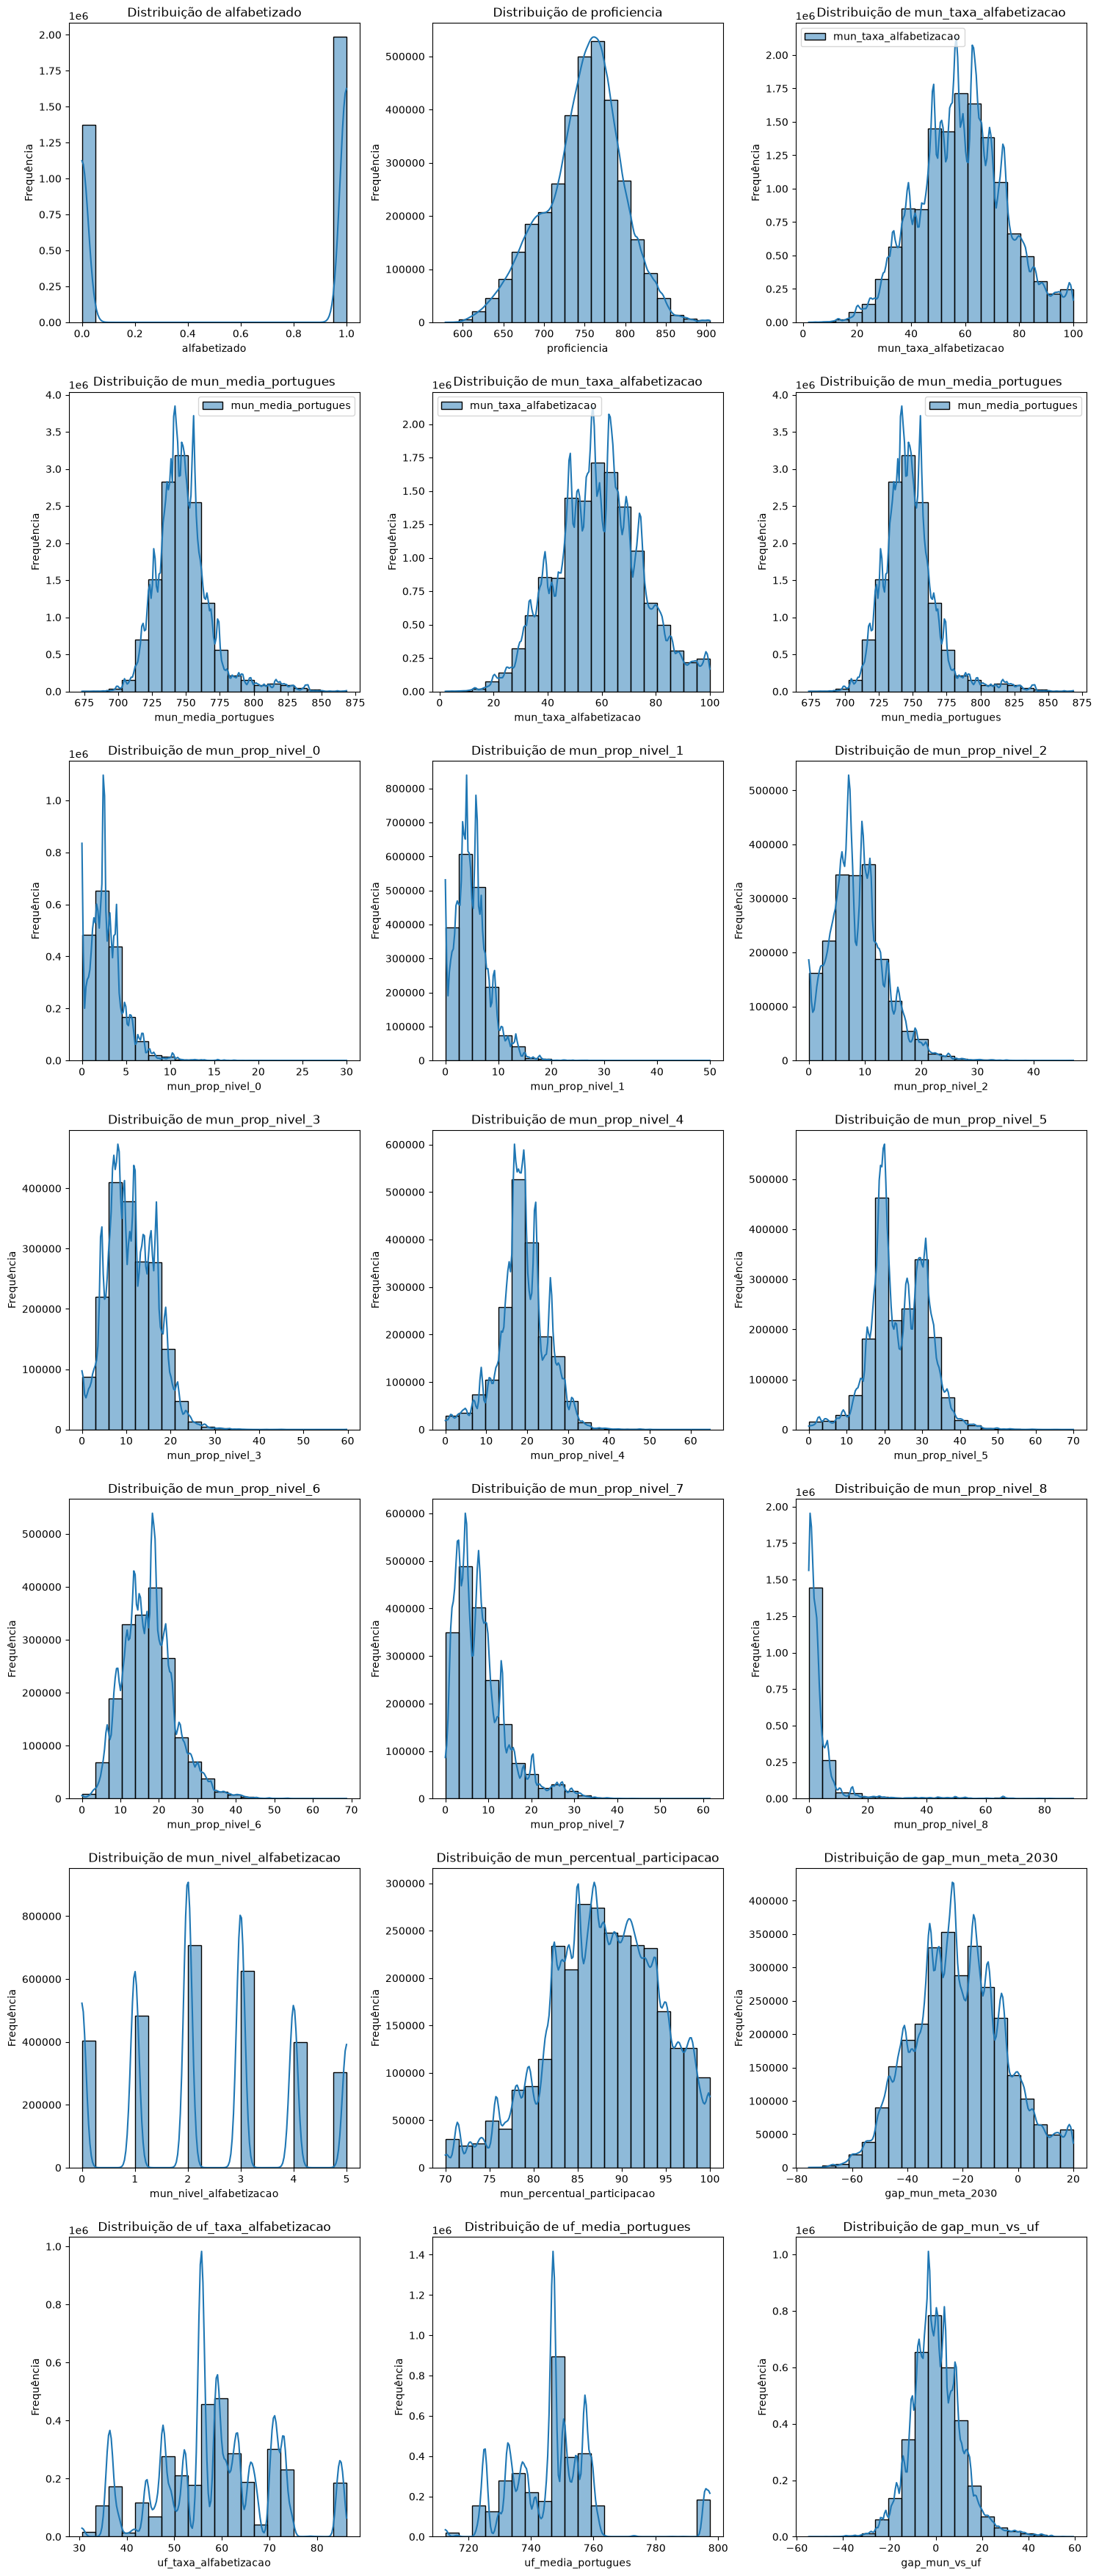

In [19]:
num_cols = len(df_dist.columns)
num_rows = (num_cols + 2) // 2 # Adjust rows based on 3 columns per row

plt.figure(figsize=(15, num_rows * 5))

for i, column in enumerate(df_dist.columns):
    plt.subplot(num_rows, 3, i + 1)
    sns.histplot(df_dist[column], bins=20, kde=True)
    plt.title(f'Distribuição de {column}')
    plt.xlabel(column)
    plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

              contagem  percentual
alfabetizado                      
1              1984530       59.14
0              1371292       40.86


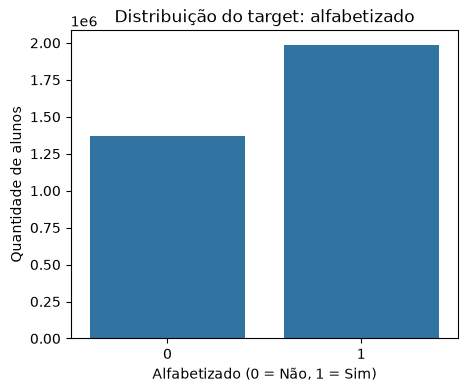

In [20]:
# analisando balanceamento da target "alfabetizado"
contagem = df["alfabetizado"].value_counts()
percentual = df["alfabetizado"].value_counts(normalize=True) * 100

resumo_target = pd.DataFrame({"contagem": contagem, "percentual": percentual.round(2)})
print(resumo_target)

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="alfabetizado")
plt.title("Distribuição do target: alfabetizado")
plt.xlabel("Alfabetizado (0 = Não, 1 = Sim)")
plt.ylabel("Quantidade de alunos")
plt.show()

In [28]:
out_lista_variaveis = [
'alfabetizado','proficiencia',
'mun_taxa_alfabetizacao',
'mun_media_portugues','mun_prop_nivel_0','mun_prop_nivel_1',
'mun_prop_nivel_2', 'mun_prop_nivel_3', 'mun_prop_nivel_4',
'mun_prop_nivel_5', 'mun_prop_nivel_6',
'mun_prop_nivel_7', 'mun_prop_nivel_8', 'mun_nivel_alfabetizacao',
'mun_percentual_participacao', 'gap_mun_meta_2030',
'uf_taxa_alfabetizacao', 'uf_media_portugues', 'gap_mun_vs_uf'
]

df_dist_alf = df[out_lista_variaveis]

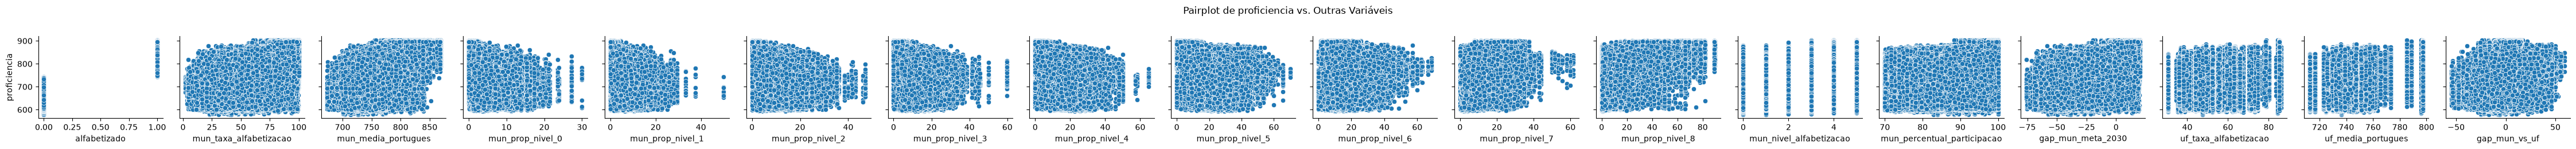

In [29]:
# comparando com target
sns.pairplot(df_dist_alf, y_vars=['proficiencia'], x_vars=df_dist_alf.drop('proficiencia', axis=1), kind='scatter')
plt.suptitle(f'Pairplot de proficiencia vs. Outras Variáveis', y=1.02)
plt.tight_layout()
plt.show()